Loading data from dublinbikes_2023_combined.csv...
Data cleaning and resampling complete.
Hourly time-series shape: (8760,)
Performing Exploratory Data Analysis (EDA)...


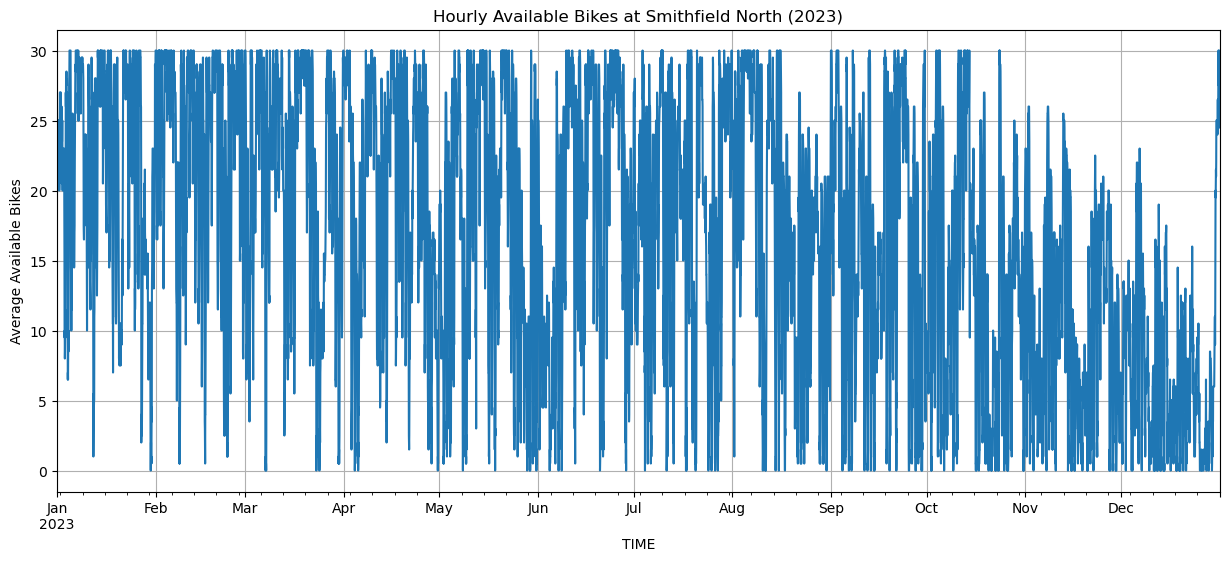

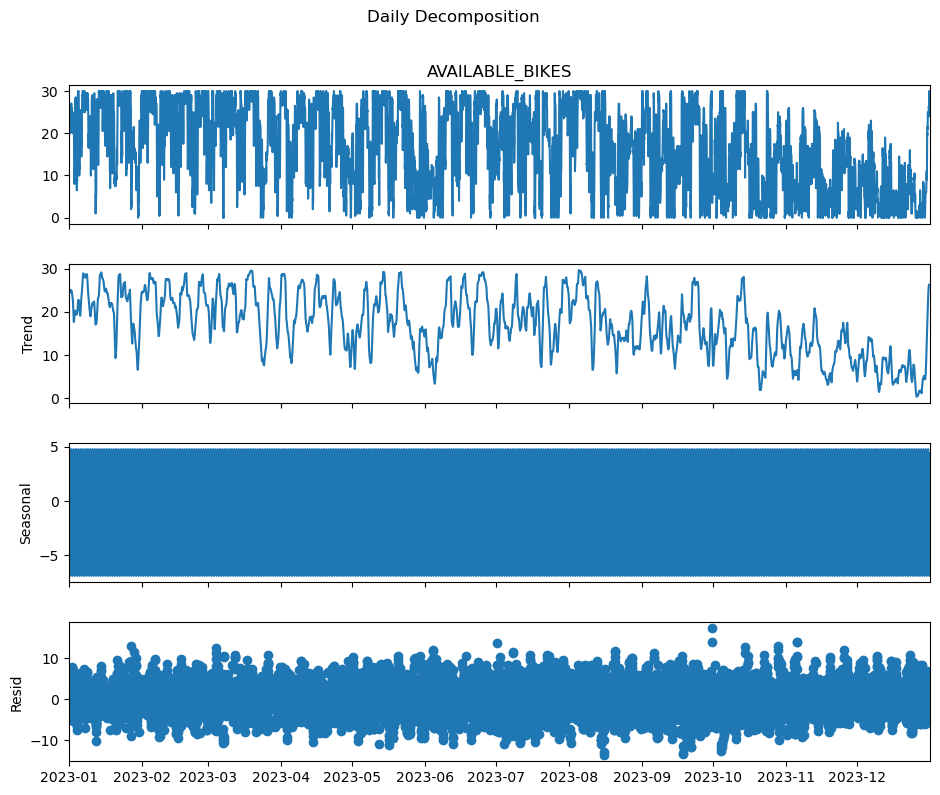

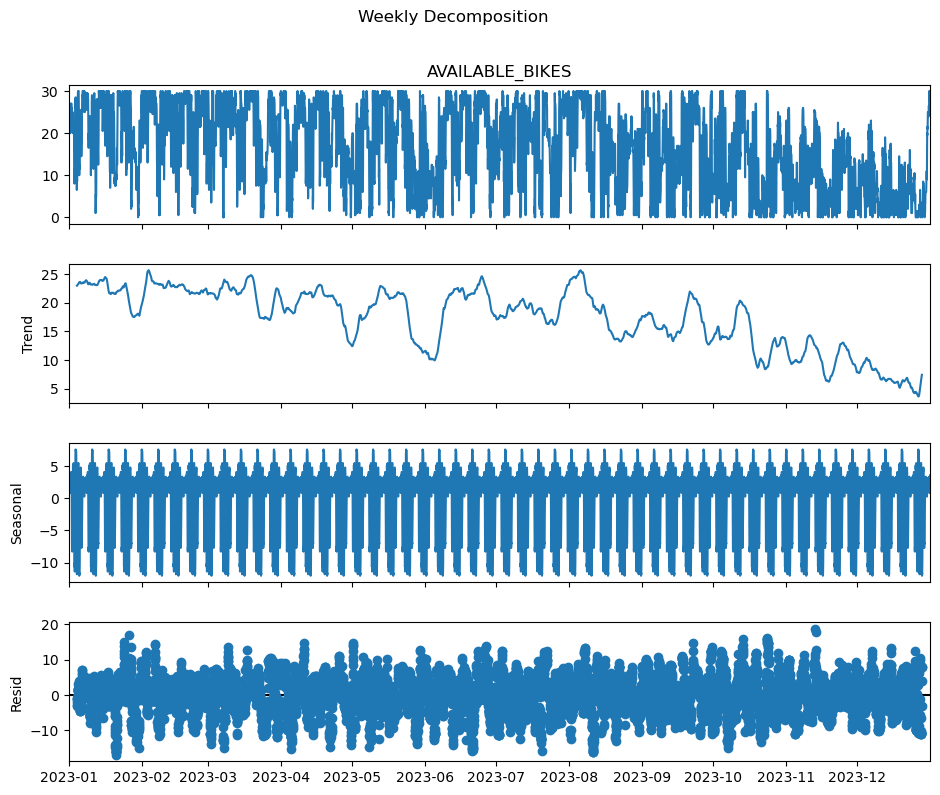

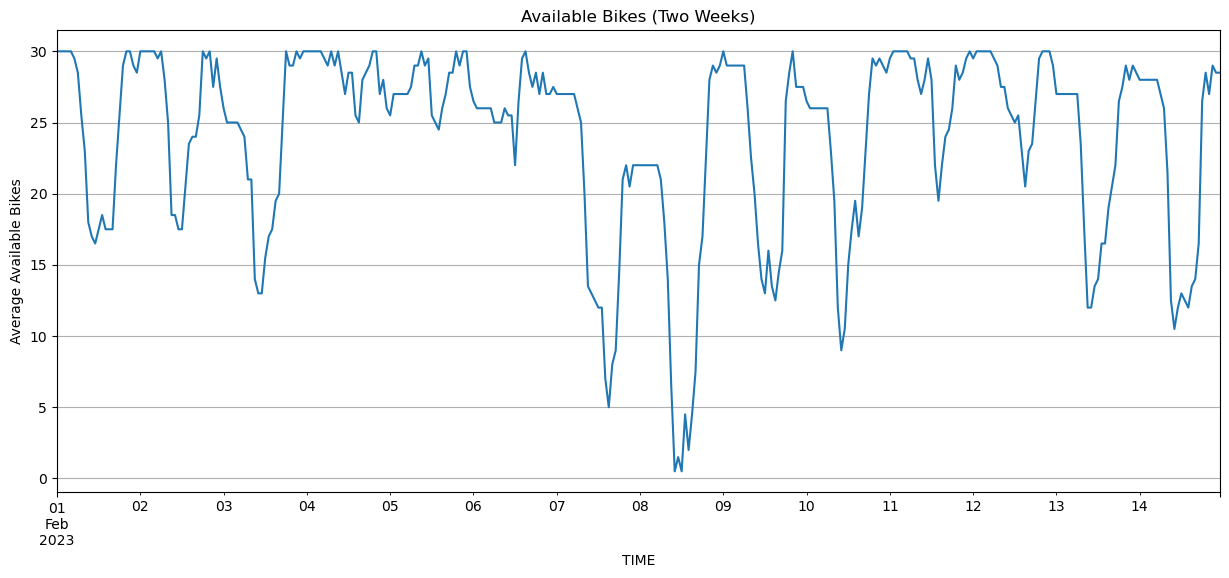

Training Prophet model...
Training data: 8016 rows
Test data: 744 rows


C:\Users\yashs\AppData\Local\Temp\ipykernel_8520\3154262043.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['cap'] = station_capacity
16:21:30 - cmdstanpy - INFO - Chain [1] start processing
16:21:32 - cmdstanpy - INFO - Chain [1] done processing


Model training and forecasting complete.
Plotting model results...


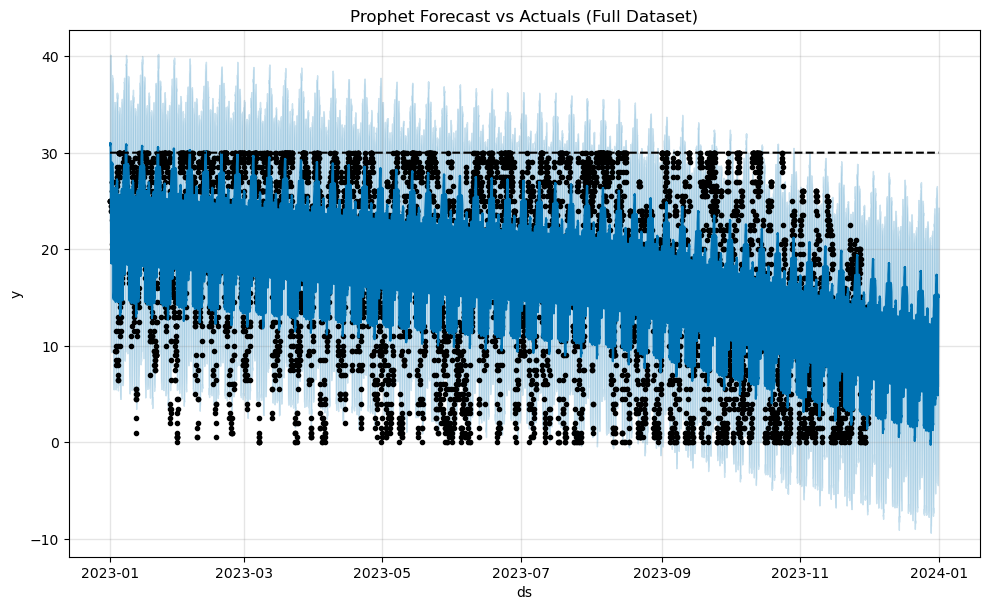

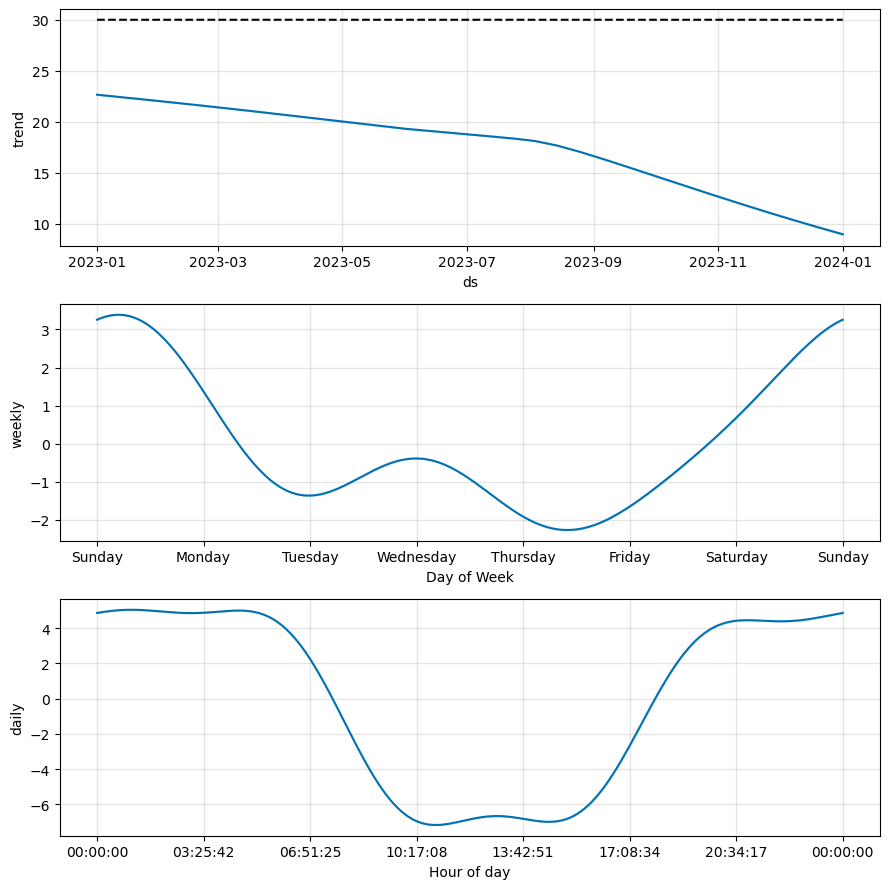

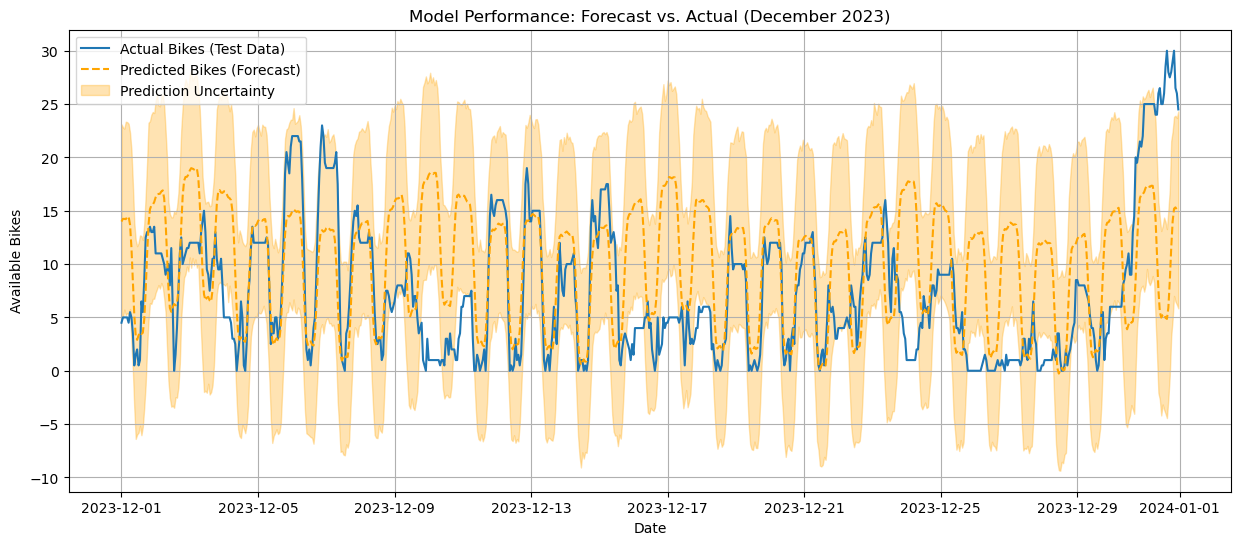

Calculating model performance metrics...

--- Model Evaluation (December 2023) ---
Average available bikes in test set: 7.43
------------------------------------------
Mean Absolute Error (MAE): 5.48 bikes
Root Mean Square Error (RMSE): 7.16 bikes

Interpretation: On average, the model's hourly forecast was off by ~5.48 bikes.

Project script executed successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import warnings

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

def load_and_prepare_data(file_path, station_id):
    """
    Loads the combined CSV, filters for one station,
    and resamples the data to an hourly frequency.
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)

    # Convert TIME column to datetime
    df['TIME'] = pd.to_datetime(df['TIME'])

    # Filter for the chosen station
    station_df = df[df['STATION ID'] == station_id].copy()
    
    if station_df.empty:
        raise ValueError(f"No data found for Station ID {station_id}")

    # Set TIME as index and sort
    station_df.set_index('TIME', inplace=True)
    station_df.sort_index(inplace=True)

    # Select target variable
    ts_data = station_df['AVAILABLE_BIKES']

    # Resample to hourly data, taking the mean
    ts_hourly = ts_data.resample('H').mean()

    # Interpolate small gaps (e.g., missing minutes within an hour)
    ts_hourly = ts_hourly.interpolate(method='time')

    # Fill any remaining NaNs (e.g., if a full hour is missing)
    ts_hourly = ts_hourly.fillna(method='bfill').fillna(method='ffill')

    print("Data cleaning and resampling complete.")
    print(f"Hourly time-series shape: {ts_hourly.shape}")
    
    return ts_hourly

def perform_eda(ts_hourly):
    """
    Performs time-series decomposition to identify patterns.
    """
    print("Performing Exploratory Data Analysis (EDA)...")
    
    # Plot the full year
    plt.figure(figsize=(15, 6))
    ts_hourly.plot(title='Hourly Available Bikes at Smithfield North (2023)', 
                   ylabel='Average Available Bikes')
    plt.grid(True)
    plt.savefig('full_year_plot.png')
    plt.show()

    # Decompose for DAILY patterns
    daily_decomposition = sm.tsa.seasonal_decompose(ts_hourly, model='additive', period=24)
    fig_daily = daily_decomposition.plot()
    fig_daily.set_size_inches(10, 8)
    plt.suptitle('Daily Decomposition', y=1.02)
    plt.savefig('daily_decomposition.png')
    plt.show()

    # Decompose for WEEKLY patterns
    weekly_decomposition = sm.tsa.seasonal_decompose(ts_hourly, model='additive', period=168)
    fig_weekly = weekly_decomposition.plot()
    fig_weekly.set_size_inches(10, 8)
    plt.suptitle('Weekly Decomposition', y=1.02)
    plt.savefig('weekly_decomposition.png')
    plt.show()
    
    # Zoom in on two typical weeks
    two_weeks = ts_hourly['2023-02-01':'2023-02-14']
    plt.figure(figsize=(15, 6))
    two_weeks.plot(title='Available Bikes (Two Weeks)', 
                   ylabel='Average Available Bikes',
                   grid=True)
    plt.savefig('two_week_zoom.png')
    plt.show()

def train_prophet_model(ts_hourly, station_capacity=30, split_date='2023-12-01'):
    """
    Prepares data, trains a Prophet model, and returns the forecast.
    """
    print("Training Prophet model...")
    
    # Prepare DataFrame for Prophet
    prophet_df = ts_hourly.reset_index()
    prophet_df.rename(columns={'TIME': 'ds', 'AVAILABLE_BIKES': 'y'}, inplace=True)

    # Create Training and Test sets
    train_data = prophet_df[prophet_df['ds'] < split_date]
    test_data = prophet_df[prophet_df['ds'] >= split_date]
    
    print(f"Training data: {train_data.shape[0]} rows")
    print(f"Test data: {test_data.shape[0]} rows")

    # Set capacity for logistic growth
    train_data['cap'] = station_capacity
    
    # Initialize and fit model
    m = Prophet(growth='logistic')
    m.fit(train_data)

    # Create future DataFrame for prediction
    future = m.make_future_dataframe(periods=test_data.shape[0], freq='H')
    future['cap'] = station_capacity
    
    # Generate forecast
    forecast = m.predict(future)
    
    print("Model training and forecasting complete.")
    
    return m, forecast, test_data

def plot_and_evaluate_model(m, forecast, test_data):
    """
    Generates plots and calculates error metrics for the model.
    """
    print("Plotting model results...")
    
    # Plot 1: Full forecast
    fig1 = m.plot(forecast)
    plt.title('Prophet Forecast vs Actuals (Full Dataset)')
    plt.savefig('full_forecast.png')
    
    # Plot 2: Model components
    fig2 = m.plot_components(forecast)
    plt.savefig('forecast_components.png')

    # Merge forecast with actual test data for comparison
    forecast_dec = forecast[forecast['ds'] >= test_data['ds'].min()]
    test_with_pred = test_data.merge(forecast_dec[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

    # Plot 3: Forecast vs. Actual (Test Set)
    plt.figure(figsize=(15, 6))
    plt.plot(test_with_pred['ds'], test_with_pred['y'], label='Actual Bikes (Test Data)')
    plt.plot(test_with_pred['ds'], test_with_pred['yhat'], label='Predicted Bikes (Forecast)', 
             color='orange', linestyle='--')
    plt.fill_between(test_with_pred['ds'], test_with_pred['yhat_lower'], test_with_pred['yhat_upper'], 
                     color='orange', alpha=0.3, label='Prediction Uncertainty')
    plt.title('Model Performance: Forecast vs. Actual (December 2023)')
    plt.ylabel('Available Bikes')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True)
    plt.savefig('forecast_test_vs_actual.png')
    
    plt.show() # Show all plots at the end

    # Calculate Error Metrics
    print("Calculating model performance metrics...")
    
    y_true = test_with_pred['y']
    y_pred = test_with_pred['yhat']
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    avg_bikes = y_true.mean()

    print("\n--- Model Evaluation (December 2023) ---")
    print(f"Average available bikes in test set: {avg_bikes:.2f}")
    print("------------------------------------------")
    print(f"Mean Absolute Error (MAE): {mae:.2f} bikes")
    print(f"Root Mean Square Error (RMSE): {rmse:.2f} bikes")
    print(f"\nInterpretation: On average, the model's hourly forecast was off by ~{mae:.2f} bikes.")

# --- Main execution ---
if __name__ == "__main__":
    
    # Configuration
    DATA_FILE = 'dublinbikes_2023_combined.csv'
    STATION_ID = 42  # Smithfield North
    STATION_CAPACITY = 30 # Approx. capacity of Smithfield North
    
    try:
        # Step 1: Load and Prep
        ts_hourly = load_and_prepare_data(DATA_FILE, STATION_ID)
        
        # Step 2: Analyze
        perform_eda(ts_hourly)
        
        # Step 3: Train Model
        model, forecast, test_data = train_prophet_model(ts_hourly, STATION_CAPACITY)
        
        # Step 4: Evaluate
        plot_and_evaluate_model(model, forecast, test_data)
        
        print("\nProject script executed successfully.")
        
    except FileNotFoundError:
        print(f"--- ERROR ---")
        print(f"Data file '{DATA_FILE}' not found.")
        print("Please download the combined data file and place it in the same directory.")
    except Exception as e:
        print(f"An error occurred: {e}")